<a href="https://colab.research.google.com/github/FadilSadBoy20/Fadil-Insanus-Siddik_2411532013_ML2526/blob/main/Praktikum1/Single_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import library yang diperlukan seperti pandas, numpy, sklearn, dan lainnya.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

Load Dataset

Pertama hubungkan (mount) Google Drive pribadi ke dalam sesi runtime Colab saat ini, karena dataset yang digunakan diletakkan di Google Drive.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Selanjutnya load file dataset advertising.csv, tampilkan size dan datanya.

In [6]:
DATA_PATH = "/content/drive/MyDrive/MachineLearningSmt4/Dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print(df.head())

Shape: (200, 4)
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


Tampilkan juga deskripsi dari dataset yang telah diload.

In [7]:
print("\nDescription stats:")
print(df.describe().T)


Description stats:
           count      mean        std  min     25%     50%      75%    max
TV         200.0  147.0425  85.854236  0.7  74.375  149.75  218.825  296.4
Radio      200.0   23.2640  14.846809  0.0   9.975   22.90   36.525   49.6
Newspaper  200.0   30.5540  21.778621  0.3  12.750   25.75   45.100  114.0
Sales      200.0   15.1305   5.283892  1.6  11.000   16.00   19.050   27.0


Visualisasikan data tersebut melalui scatterplot dengan menggunakan library matplotlib.

<Figure size 640x480 with 0 Axes>

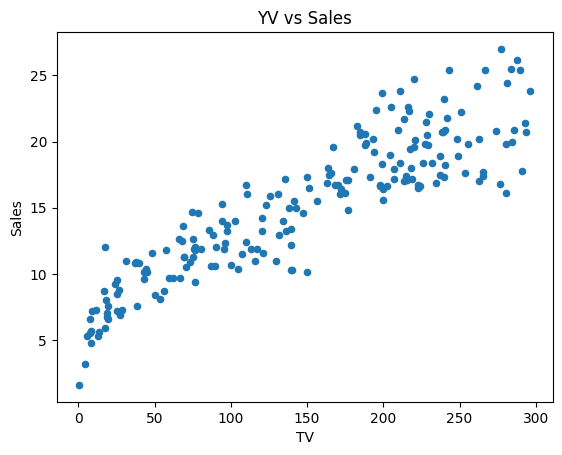

In [9]:
plt.figure()
df.plot(kind='scatter', x='TV', y='Sales')
plt.title('YV vs Sales')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.show()

Latih model regresi linear yang akan digunakan untuk memprediksi harga rumah, terlebih dahulu pisahkan variabel dependen dengan variabel independen, variabel independent yang digunakan adalah TV.

In [10]:
X = df[["TV"]]
y = df[["Sales"]]

In [11]:
reg_model = LinearRegression().fit(X, y)

print("\n=== Simple Linear Regression (Sales ~ TV) ===")
print("Intercept (b0):", reg_model.intercept_[0])
print("Coefficient TV (b1):", reg_model.coef_[0][0])


=== Simple Linear Regression (Sales ~ TV) ===
Intercept (b0): 6.974821488229891
Coefficient TV (b1): 0.055464770469558874


Lakukan prediksi penjualan jika TV = 150 dan TV = 500

In [12]:
tv_150 = reg_model.intercept_[0] + reg_model.coef_[0][0] * 150
tv_500 = reg_model.intercept_[0] + reg_model.coef_[0][0] * 500
print("Prediksi Sales jika TV = 150:", tv_150)
print("Prediksi Sales jika TV = 500:", tv_500)

Prediksi Sales jika TV = 150: 15.294537058663721
Prediksi Sales jika TV = 500: 34.70720672300933


Visualisasikan garis persamaan regresi linear yang dihasilkan setelah pelatihan model.

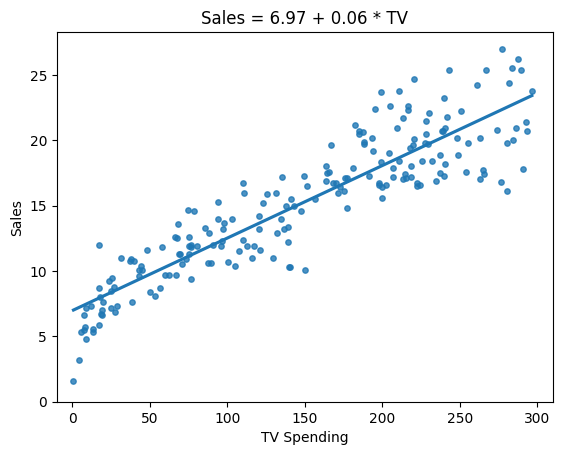

In [14]:
plt.figure()
sns.regplot(x=X, y=y, scatter_kws={'s': 15}, ci=False)
plt.title(f"Sales = {reg_model.intercept_[0]:.2f} + {reg_model.coef_[0][0]:.2f} * TV")
plt.xlabel("TV Spending")
plt.ylabel("Sales")
plt.xlim(-10, 310)
plt.ylim(bottom=0)
plt.show()